# Задача №96
# Богуславский Андрей ИУ5-61Б

In [1]:
import simpy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import pandas as pd
from collections import defaultdict

ARRIVAL_MEAN   = 300       # сек — среднее время между поступлениями
ARRIVAL_DELTA  = 60        # сек — отклонение
SIZE_MEAN      = 500       # Кбайт
SIZE_DELTA     = 200       # Кбайт
SPEED          = 100       # Кбайт/мин → время обработки = size / SPEED (мин)
ERROR_RATE     = 0.05      # 5% заданий возвращаются
SIM_TIME       = 24 * 60   # минуты (24 часа)

SEED = 42
rng  = np.random.default_rng(SEED)

print("Параметры модели загружены ✓")

Параметры модели загружены ✓


In [2]:
class Job:
    """Задание в системе."""
    _id_counter = 0

    def __init__(self, size_kb: float, arrival_time: float, is_retry: bool = False):
        Job._id_counter += 1
        self.id           = Job._id_counter
        self.size         = size_kb          # Кбайт
        self.arrival_time = arrival_time     # время первого прихода
        self.is_retry     = is_retry         # флаг повторного задания
        self.retry_count  = 0
        self.phase_times  = {}               # {phase: (start, end)}
        self.total_time   = None             # полное время пребывания

    @property
    def service_time(self) -> float:
        """Время обслуживания одной фазы (мин)."""
        return self.size / SPEED

    @property
    def priority(self) -> float:
        """Приоритет: ошибочные → -inf (обслуживаются первыми),
           остальные → сортировка по размеру (меньше = выше)."""
        return -1e9 if self.is_retry else self.size


class PriorityQueue:
    """Очередь с приоритетом (меньший ключ — первым)."""
    def __init__(self, env: simpy.Environment):
        self.env   = env
        self.items = []          # список (priority, seq, job)
        self._seq  = 0
        self._put_event = None
        self.max_length = 0
        self.length_log = []     # (time, length)

    def put(self, job: Job):
        import heapq
        self._seq += 1
        heapq.heappush(self.items, (job.priority, self._seq, job))
        self.max_length = max(self.max_length, len(self.items))
        self.length_log.append((self.env.now, len(self.items)))
        if self._put_event and not self._put_event.triggered:
            self._put_event.succeed()

    def get(self) -> Job:
        import heapq
        _, _, job = heapq.heappop(self.items)
        self.length_log.append((self.env.now, len(self.items)))
        return job

    def wait_for_item(self):
        """Возвращает событие, которое срабатывает при появлении нового элемента."""
        if self.items:
            return self.env.event().succeed()
        self._put_event = self.env.event()
        return self._put_event

    def __len__(self):
        return len(self.items)

print("Классы определены ✓")

Классы определены ✓


In [3]:
stats_data = {
    'total_arrived'    : 0,
    'total_completed'  : 0,
    'total_retries'    : 0,
    'service_times'    : [],   # полные времена пребывания
    'input_times'      : [],   # времена фазы «ввод»
    'process_times'    : [],   # времена фазы «обработка»
    'output_times'     : [],   # времена фазы «вывод»
    'queue_waits'      : defaultdict(list),  # {phase: [wait_times]}
}

print("Статистика инициализирована ✓")

Статистика инициализирована ✓


In [4]:
def job_process(env, job, queues, servers, stats_data):
    """Жизненный цикл одного задания: ввод → обработка → вывод."""
    start_full = env.now
    current_job = job

    while True:
        # ── ФАЗА ВВОД ──
        q_in = queues['input']
        q_in.put(current_job)
        enter_q = env.now
        yield q_in.wait_for_item()
        # ждём, пока наше задание окажется первым и сервер свободен
        while q_in.items[0][2] is not current_job:
            yield env.timeout(0.001)
        with servers['input'].request() as req:
            yield req
            q_in.get()  # извлекаем из очереди
            wait_in = env.now - enter_q
            stats_data['queue_waits']['input'].append(wait_in)
            t0 = env.now
            yield env.timeout(current_job.service_time)
            stats_data['input_times'].append(env.now - t0)

        # ── ФАЗА ОБРАБОТКА ──
        q_proc = queues['process']
        q_proc.put(current_job)
        enter_q = env.now
        yield q_proc.wait_for_item()
        while q_proc.items[0][2] is not current_job:
            yield env.timeout(0.001)
        with servers['process'].request() as req:
            yield req
            q_proc.get()
            wait_proc = env.now - enter_q
            stats_data['queue_waits']['process'].append(wait_proc)
            t0 = env.now
            yield env.timeout(current_job.service_time)
            stats_data['process_times'].append(env.now - t0)

        # ── ФАЗА ВЫВОД ──
        q_out = queues['output']
        q_out.put(current_job)
        enter_q = env.now
        yield q_out.wait_for_item()
        while q_out.items[0][2] is not current_job:
            yield env.timeout(0.001)
        with servers['output'].request() as req:
            yield req
            q_out.get()
            wait_out = env.now - enter_q
            stats_data['queue_waits']['output'].append(wait_out)
            t0 = env.now
            yield env.timeout(current_job.service_time)
            stats_data['output_times'].append(env.now - t0)

        # ── ПРОВЕРКА ПОСЛЕ ВЫВОДА ──
        if rng.random() < ERROR_RATE:
            # Задание выполнено неверно → возврат на ввод с приоритетом
            stats_data['total_retries'] += 1
            current_job.is_retry = True
            current_job.retry_count += 1
            # Продолжаем цикл — задание заново проходит все фазы
        else:
            # Успешное завершение
            total = env.now - start_full
            stats_data['service_times'].append(total)
            stats_data['total_completed'] += 1
            break


def job_generator(env, queues, servers, stats_data):
    """Генератор заданий."""
    while True:
        # Равномерное распределение: 300 ± 60 сек → переводим в минуты
        iat_sec = rng.uniform(ARRIVAL_MEAN - ARRIVAL_DELTA,
                               ARRIVAL_MEAN + ARRIVAL_DELTA)
        yield env.timeout(iat_sec / 60.0)   # перевод в минуты

        size = rng.uniform(SIZE_MEAN - SIZE_DELTA, SIZE_MEAN + SIZE_DELTA)
        job  = Job(size_kb=size, arrival_time=env.now)
        stats_data['total_arrived'] += 1
        env.process(job_process(env, job, queues, servers, stats_data))


print("Процессы определены ✓")

Процессы определены ✓


In [5]:
Job._id_counter = 0   # сброс счётчика
env = simpy.Environment()

# Серверы (по одному на каждую фазу)
servers = {
    'input'  : simpy.Resource(env, capacity=1),
    'process': simpy.Resource(env, capacity=1),
    'output' : simpy.Resource(env, capacity=1),
}

# Очереди с приоритетом
queues = {
    'input'  : PriorityQueue(env),
    'process': PriorityQueue(env),
    'output' : PriorityQueue(env),
}

env.process(job_generator(env, queues, servers, stats_data))
env.run(until=SIM_TIME)

print(f"Симуляция завершена (24 ч = {SIM_TIME} мин)")
print(f"  Всего поступило  : {stats_data['total_arrived']}")
print(f"  Завершено успешно: {stats_data['total_completed']}")
print(f"  Повторных запусков (ошибки): {stats_data['total_retries']}")

Симуляция завершена (24 ч = 1440 мин)
  Всего поступило  : 287
  Завершено успешно: 266
  Повторных запусков (ошибки): 23


In [6]:
print("=" * 50)
print("ЁМКОСТЬ БУФЕРОВ (максимальная длина очереди)")
print("=" * 50)
for phase in ['input', 'process', 'output']:
    q = queues[phase]
    print(f"  [{phase:8s}]  макс. длина очереди = {q.max_length} заданий")

# Рекомендуемый запас +20%
print()
print("Рекомендуемая ёмкость буфера (макс × 1.2):")
for phase in ['input', 'process', 'output']:
    rec = int(np.ceil(queues[phase].max_length * 1.2))
    print(f"  [{phase:8s}]  рекомендовано ≥ {rec} заданий")

ЁМКОСТЬ БУФЕРОВ (максимальная длина очереди)
  [input   ]  макс. длина очереди = 20 заданий
  [process ]  макс. длина очереди = 2 заданий
  [output  ]  макс. длина очереди = 2 заданий

Рекомендуемая ёмкость буфера (макс × 1.2):
  [input   ]  рекомендовано ≥ 24 заданий
  [process ]  рекомендовано ≥ 3 заданий
  [output  ]  рекомендовано ≥ 3 заданий


In [7]:
st = np.array(stats_data['service_times'])

print("=" * 50)
print("ПОЛНОЕ ВРЕМЯ ПРЕБЫВАНИЯ ЗАДАНИЯ В СИСТЕМЕ (мин)")
print("=" * 50)
print(f"  Кол-во наблюдений : {len(st)}")
print(f"  Минимум           : {st.min():.2f}")
print(f"  Максимум          : {st.max():.2f}")
print(f"  Среднее           : {st.mean():.2f}")
print(f"  Медиана           : {np.median(st):.2f}")
print(f"  Стд. отклонение   : {st.std():.2f}")
print(f"  95-й перцентиль   : {np.percentile(st, 95):.2f}")
print(f"  99-й перцентиль   : {np.percentile(st, 99):.2f}")

print()
print("СРЕДНЕЕ ВРЕМЯ ОЖИДАНИЯ В ОЧЕРЕДЯХ (мин):")
for phase in ['input', 'process', 'output']:
    w = np.array(stats_data['queue_waits'][phase])
    if len(w):
        print(f"  [{phase:8s}]  среднее = {w.mean():.3f}  макс = {w.max():.3f}")

ПОЛНОЕ ВРЕМЯ ПРЕБЫВАНИЯ ЗАДАНИЯ В СИСТЕМЕ (мин)
  Кол-во наблюдений : 266
  Минимум           : 14.27
  Максимум          : 321.50
  Среднее           : 42.01
  Медиана           : 36.92
  Стд. отклонение   : 28.03
  95-й перцентиль   : 81.54
  99-й перцентиль   : 133.67

СРЕДНЕЕ ВРЕМЯ ОЖИДАНИЯ В ОЧЕРЕДЯХ (мин):
  [input   ]  среднее = 20.151  макс = 300.988
  [process ]  среднее = 1.989  макс = 3.884
  [output  ]  среднее = 1.993  макс = 3.884


In [8]:
distributions = {
    'norm'      : stats.norm,
    'expon'     : stats.expon,
    'lognorm'   : stats.lognorm,
    'gamma'     : stats.gamma,
    'weibull_min': stats.weibull_min,
}

print("=" * 55)
print("ПОДБОР ТЕОРЕТИЧЕСКОГО ЗАКОНА (тест Колмогорова–Смирнова)")
print("=" * 55)
print(f"{'Закон':<15} {'D-статистика':>14} {'p-value':>12} {'Вывод':<12}")
print("-" * 55)

best = {'name': None, 'D': np.inf, 'params': None, 'dist': None}

for name, dist in distributions.items():
    params = dist.fit(st)
    D, p   = stats.kstest(st, dist.cdf, args=params)
    verdict = "✓ хорошо" if p > 0.05 else "✗ отвергаем"
    print(f"{name:<15} {D:>14.4f} {p:>12.4f}   {verdict}")
    if D < best['D']:
        best = {'name': name, 'D': D, 'p': p, 'params': params, 'dist': dist}

print()
print(f"Наилучшее приближение: {best['name']}  (D={best['D']:.4f}, p={best['p']:.4f})")

ПОДБОР ТЕОРЕТИЧЕСКОГО ЗАКОНА (тест Колмогорова–Смирнова)
Закон             D-статистика      p-value Вывод       
-------------------------------------------------------
norm                    0.3169       0.0000   ✗ отвергаем
expon                   0.2528       0.0000   ✗ отвергаем
lognorm                 0.1708       0.0000   ✗ отвергаем
gamma                   0.9729       0.0000   ✗ отвергаем
weibull_min             0.6180       0.0000   ✗ отвергаем

Наилучшее приближение: lognorm  (D=0.1708, p=0.0000)


/tmp/ipykernel_28379/296261415.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(wait_data, labels=['Ввод', 'Обработка', 'Вывод'],


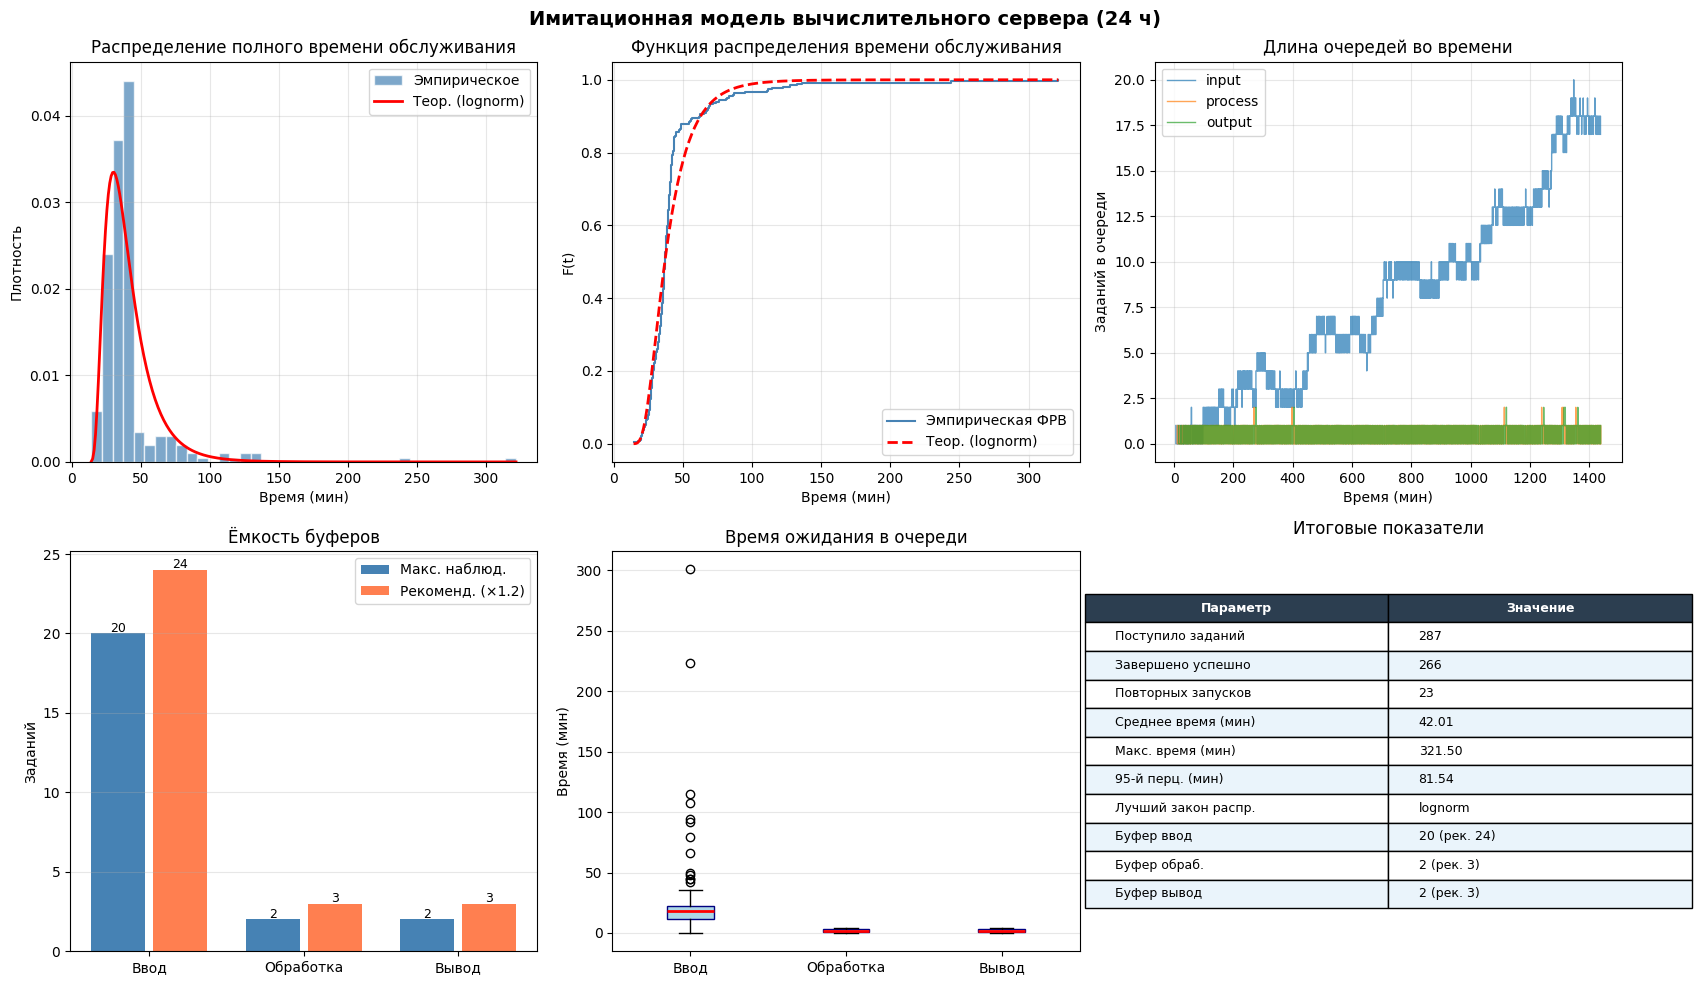

График сохранён: server_simulation_results.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Имитационная модель вычислительного сервера (24 ч)",
             fontsize=14, fontweight='bold')

# ── 1. Гистограмма полного времени обслуживания ──
ax = axes[0, 0]
ax.hist(st, bins=40, density=True, color='steelblue', alpha=0.7,
        edgecolor='white', label='Эмпирическое')
x_range = np.linspace(st.min(), st.max(), 300)
pdf_best = best['dist'].pdf(x_range, *best['params'])
ax.plot(x_range, pdf_best, 'r-', lw=2,
        label=f"Теор. ({best['name']})")
ax.set_title("Распределение полного времени обслуживания")
ax.set_xlabel("Время (мин)")
ax.set_ylabel("Плотность")
ax.legend()
ax.grid(alpha=0.3)

# ── 2. Эмпирическая ФРВ vs теоретическая ──
ax = axes[0, 1]
sorted_st = np.sort(st)
ecdf = np.arange(1, len(sorted_st) + 1) / len(sorted_st)
ax.step(sorted_st, ecdf, where='post', color='steelblue', lw=1.5,
        label='Эмпирическая ФРВ')
cdf_best = best['dist'].cdf(x_range, *best['params'])
ax.plot(x_range, cdf_best, 'r--', lw=2, label=f"Теор. ({best['name']})")
ax.set_title("Функция распределения времени обслуживания")
ax.set_xlabel("Время (мин)")
ax.set_ylabel("F(t)")
ax.legend()
ax.grid(alpha=0.3)

# ── 3. Длина очереди на ввод во времени ──
ax = axes[0, 2]
for phase, color in zip(['input', 'process', 'output'],
                         ['tab:blue', 'tab:orange', 'tab:green']):
    log = queues[phase].length_log
    if log:
        times, lengths = zip(*log)
        ax.step(times, lengths, where='post', color=color,
                alpha=0.7, label=phase, lw=1)
ax.set_title("Длина очередей во времени")
ax.set_xlabel("Время (мин)")
ax.set_ylabel("Заданий в очереди")
ax.legend()
ax.grid(alpha=0.3)

# ── 4. Ёмкость буферов (столбчатая) ──
ax = axes[1, 0]
phases  = ['input', 'process', 'output']
max_qs  = [queues[p].max_length for p in phases]
rec_qs  = [int(np.ceil(v * 1.2)) for v in max_qs]
x       = np.arange(len(phases))
ax.bar(x - 0.2, max_qs, 0.35, label='Макс. наблюд.', color='steelblue')
ax.bar(x + 0.2, rec_qs, 0.35, label='Рекоменд. (×1.2)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(['Ввод', 'Обработка', 'Вывод'])
ax.set_title("Ёмкость буферов")
ax.set_ylabel("Заданий")
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, (m, r) in enumerate(zip(max_qs, rec_qs)):
    ax.text(i - 0.2, m + 0.1, str(m), ha='center', fontsize=9)
    ax.text(i + 0.2, r + 0.1, str(r), ha='center', fontsize=9)

# ── 5. Время ожидания в очередях (box) ──
ax = axes[1, 1]
wait_data = [stats_data['queue_waits'][p] for p in phases]
bp = ax.boxplot(wait_data, labels=['Ввод', 'Обработка', 'Вывод'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', lw=2))
ax.set_title("Время ожидания в очереди")
ax.set_ylabel("Время (мин)")
ax.grid(axis='y', alpha=0.3)

# ── 6. Сводная таблица ──
ax = axes[1, 2]
ax.axis('off')
table_data = [
    ['Параметр', 'Значение'],
    ['Поступило заданий', str(stats_data['total_arrived'])],
    ['Завершено успешно', str(stats_data['total_completed'])],
    ['Повторных запусков', str(stats_data['total_retries'])],
    ['Среднее время (мин)', f"{st.mean():.2f}"],
    ['Макс. время (мин)', f"{st.max():.2f}"],
    ['95-й перц. (мин)', f"{np.percentile(st,95):.2f}"],
    ['Лучший закон распр.', best['name']],
    ['Буфер ввод', f"{queues['input'].max_length} (рек. {int(np.ceil(queues['input'].max_length*1.2))})"],
    ['Буфер обраб.', f"{queues['process'].max_length} (рек. {int(np.ceil(queues['process'].max_length*1.2))})"],
    ['Буфер вывод', f"{queues['output'].max_length} (рек. {int(np.ceil(queues['output'].max_length*1.2))})"],
]
tbl = ax.table(cellText=table_data[1:],
               colLabels=table_data[0],
               loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.3, 1.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#eaf4fb')
ax.set_title("Итоговые показатели", pad=12)

plt.tight_layout()
plt.savefig('server_simulation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: server_simulation_results.png")

In [10]:
print("=" * 60)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("=" * 60)

print("\n1. ЁМКОСТЬ БУФЕРОВ")
for phase in ['input', 'process', 'output']:
    m = queues[phase].max_length
    r = int(np.ceil(m * 1.2))
    print(f"   {phase:10s}: наблюд. макс = {m:3d},  рекоменд. ≥ {r:3d} заданий")

print("\n2. ФУНКЦИЯ РАСПРЕДЕЛЕНИЯ ВРЕМЕНИ ОБСЛУЖИВАНИЯ")
print(f"   Наилучший закон: {best['name']}")
print(f"   Параметры      : {best['params']}")
print(f"   D-статистика КС: {best['D']:.4f}")
print(f"   p-value        : {best['p']:.4f}")
if best['p'] > 0.05:
    print(f"   ✓ Гипотеза об {best['name']}-распределении НЕ отвергается (p > 0.05)")
else:
    print(f"   ✗ Ни одно стандартное распределение не подошло идеально — используем {best['name']} как наилучшее приближение")

print("\n3. ПОКАЗАТЕЛИ ПРОИЗВОДИТЕЛЬНОСТИ")
print(f"   Интенсивность потока  : ~{stats_data['total_arrived']/SIM_TIME*60:.1f} зад/ч")
print(f"   Среднее время в системе: {np.mean(st):.2f} мин")
print(f"   Доля повторных заданий : {stats_data['total_retries']/stats_data['total_arrived']*100:.1f}%  (теор. ≈ 5%+)")

ИТОГОВЫЕ ВЫВОДЫ

1. ЁМКОСТЬ БУФЕРОВ
   input     : наблюд. макс =  20,  рекоменд. ≥  24 заданий
   process   : наблюд. макс =   2,  рекоменд. ≥   3 заданий
   output    : наблюд. макс =   2,  рекоменд. ≥   3 заданий

2. ФУНКЦИЯ РАСПРЕДЕЛЕНИЯ ВРЕМЕНИ ОБСЛУЖИВАНИЯ
   Наилучший закон: lognorm
   Параметры      : (np.float64(0.5520802250428207), 11.751624006952358, np.float64(25.12853476101523))
   D-статистика КС: 0.1708
   p-value        : 0.0000
   ✗ Ни одно стандартное распределение не подошло идеально — используем lognorm как наилучшее приближение

3. ПОКАЗАТЕЛИ ПРОИЗВОДИТЕЛЬНОСТИ
   Интенсивность потока  : ~12.0 зад/ч
   Среднее время в системе: 42.01 мин
   Доля повторных заданий : 8.0%  (теор. ≈ 5%+)
